In [1]:
from pathlib import Path
import pandas as pd
import cv2

IMAGE_DIR = Path("Data/Image")
TEXT_DIR = Path("Data/Text")

print("Image folder exists:", IMAGE_DIR.exists())
print("Text folder exists:", TEXT_DIR.exists())

Image folder exists: True
Text folder exists: True


In [2]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = [
    file for file in IMAGE_DIR.rglob("*")
    if file.suffix.lower() in image_extensions
]

print("Total images found:", len(image_files))

Total images found: 400


In [3]:
sample_path = image_files[0]

image = cv2.imread(str(sample_path))

print("Image path:", sample_path)
print("Image shape:", image.shape)
print("Data type:", image.dtype)

Image path: Data\Image\Cracks\IMG_20180513_164959951_HDR resized_448.jpg
Image shape: (448, 448, 3)
Data type: uint8


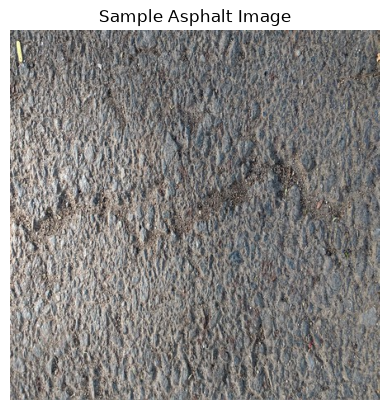

In [4]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.title("Sample Asphalt Image")
plt.show()

In [5]:
text_files = list(TEXT_DIR.glob("*"))

for file in text_files:
    print(file)

Data\Text\emails.csv


In [6]:
text_file = text_files[0]

df_text = pd.read_csv(text_file)

print("Dataset shape:", df_text.shape)

df_text.head()

Dataset shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [7]:
print(df_text.columns.tolist())

['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 'followin

In [8]:
df_text.info()

<class 'pandas.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), str(1)
memory usage: 118.5 MB


In [9]:
df_text.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

Checking if all the images have same size

In [10]:
from collections import Counter

shapes = []

for path in image_files:
    img = cv2.imread(str(path))

    if img is not None:
        shapes.append(img.shape)

shape_counts = Counter(shapes)

print("Unique image shapes:")
for shape, count in shape_counts.items():
    print(shape, "->", count, "images")

Unique image shapes:
(448, 448, 3) -> 400 images


In [11]:
IMG_SIZE = (256, 256)
resized = cv2.resize(image, IMG_SIZE)
print(resized.shape)

(256, 256, 3)


In [13]:
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

print(gray.shape)
print(gray.dtype)

(256, 256)
uint8


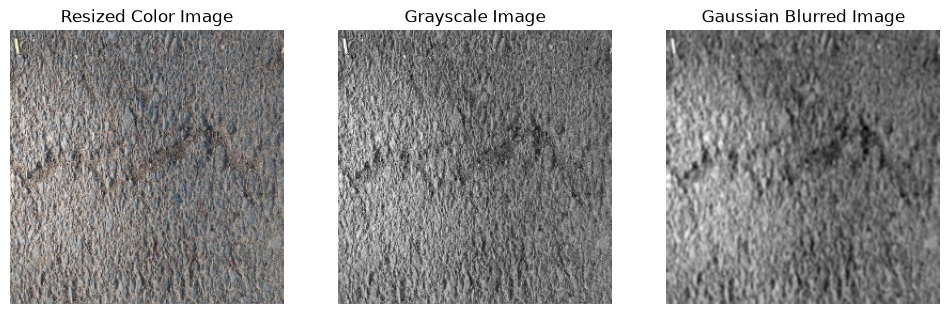

In [14]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Resized Color Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

In [15]:
edges = cv2.Canny(blurred, 100, 200)

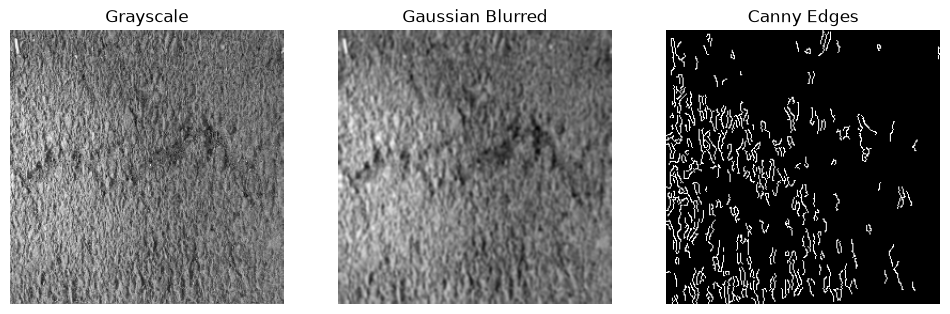

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

In [17]:
import numpy as np

def extract_features(image_path):
    image = cv2.imread(str(image_path))

    # Resize
    resized = cv2.resize(image, (256, 256))

    # Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Gaussian blur for Canny
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Canny edge detection
    edges = cv2.Canny(blurred, 100, 200)

    # Intensity features
    mean_intensity = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)

    # Pixel-ratio features
    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    # Edge features
    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / gray.size

    return [
        mean_intensity,
        contrast,
        min_intensity,
        max_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]

In [18]:
features = extract_features(image_files[0])

print(features)

[np.float64(121.95809936523438), np.float64(33.3530377060264), np.uint8(11), np.uint8(251), np.float64(0.0063934326171875), np.float64(0.0142974853515625), np.int64(4906), np.float64(0.074859619140625)]


In [19]:
feature_rows = []

for image_path in image_files:
    features = extract_features(image_path)

    feature_rows.append([
        image_path.name,
        *features
    ])

In [20]:
columns = [
    "filename",
    "mean_intensity",
    "contrast",
    "min_intensity",
    "max_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

In [21]:
df_features = pd.DataFrame(feature_rows, columns=columns)

df_features.head()

,filename,mean_intensity,contrast,min_intensity,max_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,121.958099,33.353038,11,251,0.006393,0.014297,4906,0.074860
1,IMG_20180513_165129852_HDR resized_448.jpg,131.714722,25.580155,2,245,0.003555,0.005768,1912,0.029175
2,IMG_20180513_165150613_HDR resized_448.jpg,121.036026,31.582693,1,248,0.016434,0.010468,5093,0.077713
3,IMG_20180513_165345878_HDR resized_448.jpg,130.010712,27.813358,12,253,0.003372,0.006348,3254,0.049652
4,IMG_20180513_165349788_HDR resized_448.jpg,130.882675,28.393991,6,253,0.004120,0.008453,3531,0.053879


In [22]:
print(df_features.shape)

(400, 9)


In [23]:
for path in image_files[:20]:
    print(path)

Data\Image\Cracks\IMG_20180513_164959951_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165129852_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165150613_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165345878_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165349788_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165353081_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165451567_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165455803_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165500303_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165512488_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165515651_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165521775_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165533492_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165538350_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165547907_HDR resized_448.jpg
Data\Image\Cracks\IMG_20180513_165706718_HDR resized_448.jpg
Data\Image\Cracks\IMG_20

In [24]:
feature_rows = []

for image_path in image_files:
    features = extract_features(image_path)

    folder_name = image_path.parent.name.lower()

    if "crack" in folder_name and "non" not in folder_name:
        label = 1
    else:
        label = 0

    feature_rows.append([
        image_path.name,
        *features,
        label
    ])

In [25]:
columns = [
    "filename",
    "mean_intensity",
    "contrast",
    "min_intensity",
    "max_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density",
    "label"
]

In [26]:
df_features = pd.DataFrame(feature_rows, columns=columns)

df_features.head()

,filename,mean_intensity,contrast,min_intensity,max_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,121.958099,33.353038,11,251,0.006393,0.014297,4906,0.074860,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.714722,25.580155,2,245,0.003555,0.005768,1912,0.029175,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.036026,31.582693,1,248,0.016434,0.010468,5093,0.077713,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.010712,27.813358,12,253,0.003372,0.006348,3254,0.049652,1
4,IMG_20180513_165349788_HDR resized_448.jpg,130.882675,28.393991,6,253,0.004120,0.008453,3531,0.053879,1


In [27]:
df_features["label"].value_counts()
df_features.groupby("label").size()

label
0    200
1    200
dtype: int64

In [28]:
df_features.groupby("label")[
    [
        "mean_intensity",
        "contrast",
        "min_intensity",
        "max_intensity",
        "dark_pixel_ratio",
        "bright_pixel_ratio",
        "edge_count",
        "edge_density"
    ]
].mean()

,mean_intensity,contrast,min_intensity,max_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density
label,,,,,,,,
0,157.400063,24.764322,59.07,251.695,0.000724,0.049785,1875.985,0.028625
1,144.135855,31.584401,25.04,252.270,0.009548,0.075593,6565.835,0.100187


<Figure size 600x400 with 0 Axes>

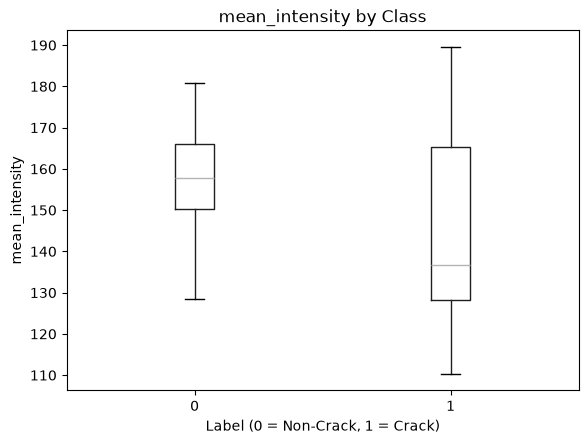

<Figure size 600x400 with 0 Axes>

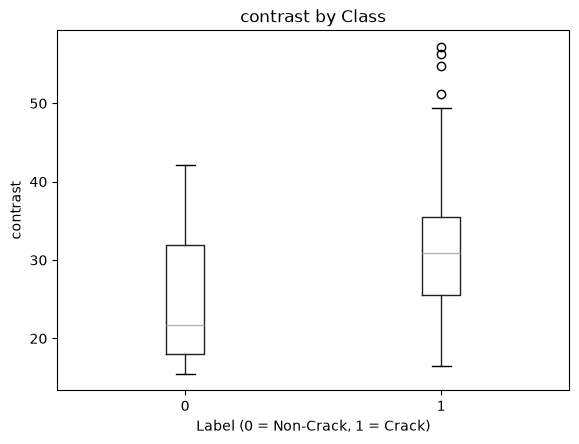

<Figure size 600x400 with 0 Axes>

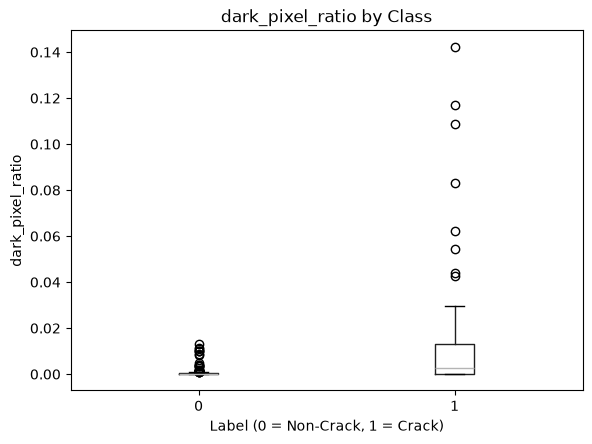

<Figure size 600x400 with 0 Axes>

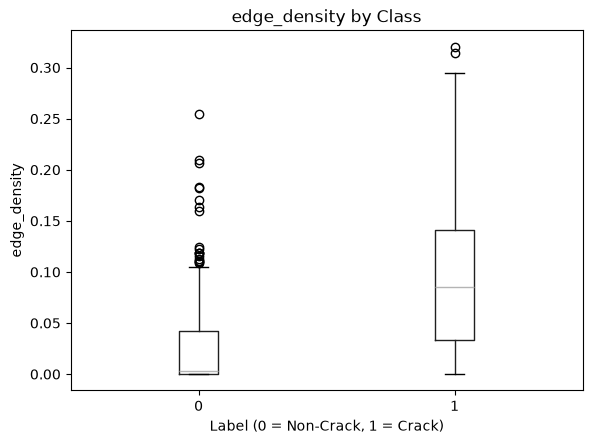

In [29]:
import matplotlib.pyplot as plt

features_to_plot = [
    "mean_intensity",
    "contrast",
    "dark_pixel_ratio",
    "edge_density"
]

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))

    df_features.boxplot(
        column=feature,
        by="label",
        grid=False
    )

    plt.title(f"{feature} by Class")
    plt.suptitle("")
    plt.xlabel("Label (0 = Non-Crack, 1 = Crack)")
    plt.ylabel(feature)

    plt.show()

In [30]:
df_features.groupby("label")[
    [
        "mean_intensity",
        "contrast",
        "dark_pixel_ratio",
        "edge_density"
    ]
].agg(["mean", "std", "min", "max"])

mean_intensity                                      contrast            \
                mean        std         min         max       mean       std   
label                                                                          
0         157.400063  10.646168  128.428879  180.755478  24.764322  7.690322   
1         144.135855  20.752704  110.244156  189.581635  31.584401  7.982816   

                            dark_pixel_ratio                           \
             min        max             mean       std  min       max   
label                                                                   
0      15.436976  42.078264         0.000724  0.002126  0.0  0.013062   
1      16.481046  57.205592         0.009548  0.018075  0.0  0.142273   

      edge_density                                
              mean       std       min       max  
label                                             
0         0.028625  0.047263  0.000000  0.254715  
1         0.100187  0.079856  0.000244  0.320297

In [31]:
feature_columns = [
    "mean_intensity",
    "contrast",
    "min_intensity",
    "max_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

X = df_features[feature_columns]
y = df_features["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 8)
y shape: (400,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training shape: (320, 8)
Test shape: (80, 8)

Training class distribution:
label
1    160
0    160
Name: count, dtype: int64

Test class distribution:
label
0    40
1    40
Name: count, dtype: int64


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[-3.19189120e-16 -1.94289029e-17 -7.77156117e-17 -2.49800181e-17
 -2.49800181e-17  0.00000000e+00 -8.60422844e-17 -8.60422844e-17]
[1. 1. 1. 1. 1. 1. 1. 1.]


In [35]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

model = LogisticRegression(random_state=42)

# Training time
start_train = time.perf_counter()
model.fit(X_train_scaled, y_train)
end_train = time.perf_counter()

training_time = end_train - start_train

# Prediction time
start_pred = time.perf_counter()
y_pred = model.predict(X_test_scaled)
end_pred = time.perf_counter()

prediction_time = end_pred - start_pred

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision:       {precision:.4f}")
print(f"Recall:          {recall:.4f}")
print(f"F1-score:        {f1:.4f}")
print(f"Training time:   {training_time * 1000:.3f} ms")
print(f"Prediction time: {prediction_time * 1000:.3f} ms")

print("\nConfusion Matrix:")
print(cm)

Accuracy:        0.9125
Precision:       0.9231
Recall:          0.9000
F1-score:        0.9114
Training time:   16.350 ms
Prediction time: 0.514 ms

Confusion Matrix:
[[37  3]
 [ 4 36]]


Testing with other models To know the Presicion and Accuracy

In [36]:
import time
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [37]:
results = []

for name, model in models.items():

    if name == "Logistic Regression":
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train
        X_test_model = X_test

    # Train
    start = time.perf_counter()
    model.fit(X_train_model, y_train)
    training_time = time.perf_counter() - start

    # Predict
    start = time.perf_counter()
    y_pred = model.predict(X_test_model)
    prediction_time = time.perf_counter() - start

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Training Time (ms)": training_time * 1000,
        "Prediction Time (ms)": prediction_time * 1000
    })

In [38]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time (ms),Prediction Time (ms)
0,Logistic Regression,0.9125,0.923077,0.900,0.911392,5.9603,0.3113
1,Decision Tree,0.9250,0.925000,0.925,0.925000,4.2078,1.2953
2,Random Forest,0.9500,0.950000,0.950,0.950000,159.5359,11.7844


[[38  2]
 [ 2 38]]


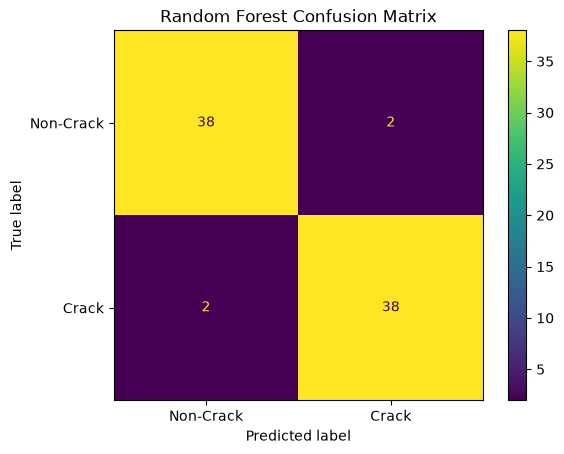

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_model = models["Random Forest"]

y_pred_rf = rf_model.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [40]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,bright_pixel_ratio,0.189100
0,mean_intensity,0.186209
2,min_intensity,0.155701
7,edge_density,0.136985
6,edge_count,0.121935
4,dark_pixel_ratio,0.111300
1,contrast,0.082836
3,max_intensity,0.015934


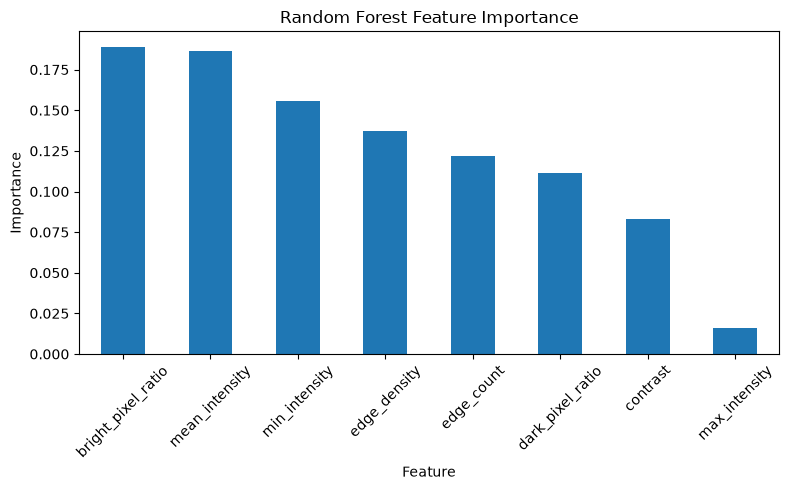

In [41]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
improved_feature_columns = [
    "mean_intensity",
    "contrast",
    "min_intensity",
    "max_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_density"
]

X_improved = df_features[improved_feature_columns]
y_improved = df_features["label"]

In [43]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.2,
    random_state=42,
    stratify=y_improved
)

In [44]:
rf_improved = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.perf_counter()
rf_improved.fit(X_train_imp, y_train_imp)
train_time_imp = time.perf_counter() - start

start = time.perf_counter()
y_pred_imp = rf_improved.predict(X_test_imp)
pred_time_imp = time.perf_counter() - start

In [45]:
print("Accuracy:", accuracy_score(y_test_imp, y_pred_imp))
print("Precision:", precision_score(y_test_imp, y_pred_imp))
print("Recall:", recall_score(y_test_imp, y_pred_imp))
print("F1-score:", f1_score(y_test_imp, y_pred_imp))
print("Training time (ms):", train_time_imp * 1000)
print("Prediction time (ms):", pred_time_imp * 1000)
print("Confusion matrix:")
print(confusion_matrix(y_test_imp, y_pred_imp))

Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1-score: 0.95
Training time (ms): 159.0256000054069
Prediction time (ms): 11.077600007411093
Confusion matrix:
[[38  2]
 [ 2 38]]


In [46]:
comparison_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": 8,
        "Accuracy": 0.9125,
        "Precision": 0.9231,
        "Recall": 0.9000,
        "F1-score": 0.9114,
        "Training Time (ms)": 7.4354,
        "Prediction Time (ms)": 0.3202
    },
    {
        "Model": "Decision Tree",
        "Features": 8,
        "Accuracy": 0.9250,
        "Precision": 0.9250,
        "Recall": 0.9250,
        "F1-score": 0.9250,
        "Training Time (ms)": 5.7607,
        "Prediction Time (ms)": 1.2417
    },
    {
        "Model": "Random Forest",
        "Features": 8,
        "Accuracy": 0.9500,
        "Precision": 0.9500,
        "Recall": 0.9500,
        "F1-score": 0.9500,
        "Training Time (ms)": 149.1631,
        "Prediction Time (ms)": 7.8359
    },
    {
        "Model": "Random Forest - Improved",
        "Features": 7,
        "Accuracy": 0.9500,
        "Precision": 0.9500,
        "Recall": 0.9500,
        "F1-score": 0.9500,
        "Training Time (ms)": 159.0256,
        "Prediction Time (ms)": 11.0776
    }
])

comparison_table

,Model,Features,Accuracy,Precision,Recall,F1-score,Training Time (ms),Prediction Time (ms)
0,Logistic Regression,8,0.9125,0.9231,0.900,0.9114,7.4354,0.3202
1,Decision Tree,8,0.9250,0.9250,0.925,0.9250,5.7607,1.2417
2,Random Forest,8,0.9500,0.9500,0.950,0.9500,149.1631,7.8359
3,Random Forest - Improved,7,0.9500,0.9500,0.950,0.9500,159.0256,11.0776


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import time

tuned_lr = LogisticRegression(
    C=0.01,
    random_state=42,
    max_iter=1000
)

# Train
start = time.perf_counter()
tuned_lr.fit(X_train_scaled, y_train)
training_time_tuned = time.perf_counter() - start

# Predict
start = time.perf_counter()
y_pred_tuned = tuned_lr.predict(X_test_scaled)
prediction_time_tuned = time.perf_counter() - start

# Metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"Accuracy:        {accuracy_tuned:.4f}")
print(f"Precision:       {precision_tuned:.4f}")
print(f"Recall:          {recall_tuned:.4f}")
print(f"F1-score:        {f1_tuned:.4f}")
print(f"Training time:   {training_time_tuned * 1000:.3f} ms")
print(f"Prediction time: {prediction_time_tuned * 1000:.3f} ms")

print("\nConfusion Matrix:")
print(cm_tuned)

Accuracy:        0.7875
Precision:       0.8286
Recall:          0.7250
F1-score:        0.7733
Training time:   178.883 ms
Prediction time: 6.277 ms

Confusion Matrix:
[[34  6]
 [11 29]]


In [58]:
lr_comparison = pd.DataFrame([
    {
        "Model": "Baseline Logistic Regression",
        "C": 1.0,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    },
    {
        "Model": "Tuned Logistic Regression",
        "C": 0.01,
        "Accuracy": accuracy_tuned,
        "Precision": precision_tuned,
        "Recall": recall_tuned,
        "F1-score": f1_tuned
    }
])

lr_comparison.style.format({
    "C": "{:.2f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}"
})

,Model,C,Accuracy,Precision,Recall,F1-score
0,Baseline Logistic Regression,1.00,0.9125,0.9231,0.9000,0.9114
1,Tuned Logistic Regression,0.01,0.7875,0.8286,0.7250,0.7733


In [59]:
C_values = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100]

lr_tuning_results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        random_state=42,
        max_iter=1000
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    lr_tuning_results.append({
        "C": C,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

lr_tuning_df = pd.DataFrame(lr_tuning_results)

lr_tuning_df

,C,Accuracy,Precision,Recall,F1-score
0,0.001,0.7375,0.771429,0.675,0.720000
1,0.010,0.7875,0.828571,0.725,0.773333
2,0.100,0.9000,0.921053,0.875,0.897436
3,0.500,0.9250,0.947368,0.900,0.923077
4,1.000,0.9125,0.923077,0.900,0.911392
5,5.000,0.9125,0.923077,0.900,0.911392
6,10.000,0.9250,0.925000,0.925,0.925000
7,100.000,0.9250,0.925000,0.925,0.925000


In [60]:
lr_tuning_df.sort_values(
    by="F1-score",
    ascending=False
)

,C,Accuracy,Precision,Recall,F1-score
6,10.000,0.9250,0.925000,0.925,0.925000
7,100.000,0.9250,0.925000,0.925,0.925000
3,0.500,0.9250,0.947368,0.900,0.923077
5,5.000,0.9125,0.923077,0.900,0.911392
4,1.000,0.9125,0.923077,0.900,0.911392
2,0.100,0.9000,0.921053,0.875,0.897436
1,0.010,0.7875,0.828571,0.725,0.773333
0,0.001,0.7375,0.771429,0.675,0.720000


In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=5
)

grid.fit(X_train_scaled, y_train)

print("Best C:", grid.best_params_["C"])
print("Best CV F1:", grid.best_score_)

Best C: 10
Best CV F1: 0.9349765388011656


In [62]:
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_best))

Accuracy: 0.925
Precision: 0.925
Recall: 0.925
F1-score: 0.925
Confusion matrix:
[[37  3]
 [ 3 37]]


In [63]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression - Baseline",
        "Features": 8,
        "Accuracy": 0.9125,
        "Precision": 0.923077,
        "Recall": 0.9000,
        "F1-score": 0.911392,
        "Notes": "Default C = 1.0"
    },

    {
        "Model": "Logistic Regression - Tuned",
        "Features": 8,
        "Accuracy": 0.9250,
        "Precision": 0.9250,
        "Recall": 0.9250,
        "F1-score": 0.9250,
        "Notes": f"Best C = {grid.best_params_['C']}"
    },

    {
        "Model": "Decision Tree",
        "Features": 8,
        "Accuracy": 0.9250,
        "Precision": 0.9250,
        "Recall": 0.9250,
        "F1-score": 0.9250,
        "Notes": "Baseline Decision Tree"
    },

    {
        "Model": "Random Forest",
        "Features": 8,
        "Accuracy": 0.9500,
        "Precision": 0.9500,
        "Recall": 0.9500,
        "F1-score": 0.9500,
        "Notes": "100 trees"
    },

    {
        "Model": "Random Forest - Reduced Features",
        "Features": 7,
        "Accuracy": 0.9500,
        "Precision": 0.9500,
        "Recall": 0.9500,
        "F1-score": 0.9500,
        "Notes": "Removed redundant edge_count"
    }
])

In [64]:
final_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}"
}).set_caption("Final Image Classification Model Comparison")

,Model,Features,Accuracy,Precision,Recall,F1-score,Notes
0,Logistic Regression - Baseline,8,0.9125,0.9231,0.9000,0.9114,Default C = 1.0
1,Logistic Regression - Tuned,8,0.9250,0.9250,0.9250,0.9250,Best C = 10
2,Decision Tree,8,0.9250,0.9250,0.9250,0.9250,Baseline Decision Tree
3,Random Forest,8,0.9500,0.9500,0.9500,0.9500,100 trees
4,Random Forest - Reduced Features,7,0.9500,0.9500,0.9500,0.9500,Removed redundant edge_count


In [50]:
df_text["Prediction"].value_counts()

Prediction
0    3672
1    1500
Name: count, dtype: int64

In [51]:
df_text["Prediction"].value_counts(normalize=True)

Prediction
0    0.709977
1    0.290023
Name: proportion, dtype: float64

In [52]:
print(df_text.columns[:20].tolist())

['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have']


In [53]:
df_text.iloc[0, :20]

Email No.    Email 1
the                0
to                 0
ect                1
and                0
for                0
of                 0
a                  2
you                0
hou                0
in                 0
on                 0
is                 1
this               0
enron              0
i                  2
be                 0
that               0
will               0
have               0
Name: 0, dtype: object

In [54]:
word_columns = df_text.columns[1:-1]

In [55]:
def reconstruct_email(row):
    words = []

    for word in word_columns:
        count = int(row[word])

        if count > 0:
            words.extend([word] * count)

    return " ".join(words)

In [65]:
df_text = df_text.copy()

df_text["reconstructed_text"] = df_text.apply(
    reconstruct_email,
    axis=1
)


In [66]:
X_text = df_text["reconstructed_text"]
y_text = df_text["Prediction"]

print("Text samples:", X_text.shape)
print("\nClass distribution:")
print(y_text.value_counts())

Text samples: (5172,)

Class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


In [67]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text
)

print("Training emails:", len(X_train_text))
print("Testing emails:", len(X_test_text))

print("\nTraining class distribution:")
print(y_train_text.value_counts())

print("\nTesting class distribution:")
print(y_test_text.value_counts())

Training emails: 4137
Testing emails: 1035

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


In [68]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train_vector = vectorizer.fit_transform(X_train_text)
X_test_vector = vectorizer.transform(X_test_text)

print("Training vector shape:", X_train_vector.shape)
print("Testing vector shape:", X_test_vector.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Training vector shape: (4137, 2974)
Testing vector shape: (1035, 2974)
Vocabulary size: 2974


In [69]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

text_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training time
start = time.perf_counter()
text_lr.fit(X_train_vector, y_train_text)
train_time_text_lr = time.perf_counter() - start

# Prediction time
start = time.perf_counter()
y_pred_text_lr = text_lr.predict(X_test_vector)
pred_time_text_lr = time.perf_counter() - start

# Metrics
text_lr_accuracy = accuracy_score(y_test_text, y_pred_text_lr)
text_lr_precision = precision_score(y_test_text, y_pred_text_lr)
text_lr_recall = recall_score(y_test_text, y_pred_text_lr)
text_lr_f1 = f1_score(y_test_text, y_pred_text_lr)

print(f"Accuracy:        {text_lr_accuracy:.4f}")
print(f"Precision:       {text_lr_precision:.4f}")
print(f"Recall:          {text_lr_recall:.4f}")
print(f"F1-score:        {text_lr_f1:.4f}")
print(f"Training time:   {train_time_text_lr * 1000:.3f} ms")
print(f"Prediction time: {pred_time_text_lr * 1000:.3f} ms")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_text, y_pred_text_lr))

Accuracy:        0.9807
Precision:       0.9545
Recall:          0.9800
F1-score:        0.9671
Training time:   346.174 ms
Prediction time: 9.166 ms

Confusion Matrix:
[[721  14]
 [  6 294]]


In [70]:
from sklearn.naive_bayes import MultinomialNB

text_nb = MultinomialNB()

start = time.perf_counter()
text_nb.fit(X_train_vector, y_train_text)
train_time_nb = time.perf_counter() - start

start = time.perf_counter()
y_pred_nb = text_nb.predict(X_test_vector)
pred_time_nb = time.perf_counter() - start

nb_accuracy = accuracy_score(y_test_text, y_pred_nb)
nb_precision = precision_score(y_test_text, y_pred_nb)
nb_recall = recall_score(y_test_text, y_pred_nb)
nb_f1 = f1_score(y_test_text, y_pred_nb)

print(f"Accuracy:        {nb_accuracy:.4f}")
print(f"Precision:       {nb_precision:.4f}")
print(f"Recall:          {nb_recall:.4f}")
print(f"F1-score:        {nb_f1:.4f}")
print(f"Training time:   {train_time_nb * 1000:.3f} ms")
print(f"Prediction time: {pred_time_nb * 1000:.3f} ms")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_text, y_pred_nb))

Accuracy:        0.9420
Precision:       0.8681
Recall:          0.9433
F1-score:        0.9042
Training time:   10.348 ms
Prediction time: 1.990 ms

Confusion Matrix:
[[692  43]
 [ 17 283]]


In [71]:
from sklearn.feature_extraction.text import CountVectorizer

improved_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000
)

X_train_vector_imp = improved_vectorizer.fit_transform(X_train_text)
X_test_vector_imp = improved_vectorizer.transform(X_test_text)

print("Improved training shape:", X_train_vector_imp.shape)
print("Improved testing shape:", X_test_vector_imp.shape)
print("Improved vocabulary size:", len(improved_vectorizer.vocabulary_))

Improved training shape: (4137, 5000)
Improved testing shape: (1035, 5000)
Improved vocabulary size: 5000


In [72]:
text_lr_imp = LogisticRegression(
    max_iter=1000,
    random_state=42
)

start = time.perf_counter()
text_lr_imp.fit(X_train_vector_imp, y_train_text)
train_time_text_imp = time.perf_counter() - start

start = time.perf_counter()
y_pred_text_imp = text_lr_imp.predict(X_test_vector_imp)
pred_time_text_imp = time.perf_counter() - start

imp_accuracy = accuracy_score(y_test_text, y_pred_text_imp)
imp_precision = precision_score(y_test_text, y_pred_text_imp)
imp_recall = recall_score(y_test_text, y_pred_text_imp)
imp_f1 = f1_score(y_test_text, y_pred_text_imp)

print(f"Accuracy:        {imp_accuracy:.4f}")
print(f"Precision:       {imp_precision:.4f}")
print(f"Recall:          {imp_recall:.4f}")
print(f"F1-score:        {imp_f1:.4f}")
print(f"Training time:   {train_time_text_imp * 1000:.3f} ms")
print(f"Prediction time: {pred_time_text_imp * 1000:.3f} ms")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_text, y_pred_text_imp))

Accuracy:        0.9739
Precision:       0.9446
Recall:          0.9667
F1-score:        0.9555
Training time:   310.213 ms
Prediction time: 1.620 ms

Confusion Matrix:
[[718  17]
 [ 10 290]]


In [73]:
text_comparison = pd.DataFrame([
    {
        "Representation": "Baseline CountVectorizer",
        "Vocabulary Size": X_train_vector.shape[1],
        "Accuracy": text_lr_accuracy,
        "Precision": text_lr_precision,
        "Recall": text_lr_recall,
        "F1-score": text_lr_f1,
        "Training Time (ms)": train_time_text_lr * 1000,
        "Prediction Time (ms)": pred_time_text_lr * 1000
    },
    {
        "Representation": "Improved CountVectorizer",
        "Vocabulary Size": X_train_vector_imp.shape[1],
        "Accuracy": imp_accuracy,
        "Precision": imp_precision,
        "Recall": imp_recall,
        "F1-score": imp_f1,
        "Training Time (ms)": train_time_text_imp * 1000,
        "Prediction Time (ms)": pred_time_text_imp * 1000
    }
])

text_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "Training Time (ms)": "{:.3f}",
    "Prediction Time (ms)": "{:.3f}"
})

,Representation,Vocabulary Size,Accuracy,Precision,Recall,F1-score,Training Time (ms),Prediction Time (ms)
0,Baseline CountVectorizer,2974,0.9807,0.9545,0.9800,0.9671,346.174,9.166
1,Improved CountVectorizer,5000,0.9739,0.9446,0.9667,0.9555,310.213,1.620


In [74]:
final_text_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Representation": "Baseline CountVectorizer",
        "Vocabulary Size": 2974,
        "Accuracy": 0.9807,
        "Precision": 0.9545,
        "Recall": 0.9800,
        "F1-score": 0.9671,
        "Training Time (ms)": 346.174,
        "Prediction Time (ms)": 9.166,
        "Notes": "Best baseline text result"
    },

    {
        "Model": "Multinomial Naive Bayes",
        "Representation": "Baseline CountVectorizer",
        "Vocabulary Size": 2974,
        "Accuracy": 0.9420,
        "Precision": 0.8681,
        "Recall": 0.9433,
        "F1-score": 0.9042,
        "Training Time (ms)": 10.348,
        "Prediction Time (ms)": 1.990,
        "Notes": "Much faster, lower predictive performance"
    },

    {
        "Model": "Logistic Regression",
        "Representation": "Improved CountVectorizer",
        "Vocabulary Size": 5000,
        "Accuracy": 0.9739,
        "Precision": 0.9446,
        "Recall": 0.9667,
        "F1-score": 0.9555,
        "Training Time (ms)": 310.213,
        "Prediction Time (ms)": 1.620,
        "Notes": "Stop words removed + unigrams/bigrams"
    }
])

final_text_comparison

,Model,Representation,Vocabulary Size,Accuracy,Precision,Recall,F1-score,Training Time (ms),Prediction Time (ms),Notes
0,Logistic Regression,Baseline CountVectorizer,2974,0.9807,0.9545,0.9800,0.9671,346.174,9.166,Best baseline text result
1,Multinomial Naive Bayes,Baseline CountVectorizer,2974,0.9420,0.8681,0.9433,0.9042,10.348,1.990,"Much faster, lower predictive performance"
2,Logistic Regression,Improved CountVectorizer,5000,0.9739,0.9446,0.9667,0.9555,310.213,1.620,Stop words removed + unigrams/bigrams
